# 실무로 통하는 인과추론 with 파이썬

## Week 03 - 1장 인과추론 소개

### 인과추론의 목적

원인과 결과의 관계를 알아야 원인에 **개입**하여 원하는 결과를 얻을 수 있다.  
인과추론은 다음과 같은 질문들에 대해 답하기 위한 의사결정 과학의 한 분야
- 1) 현재 상품의 권장 가격 대신 다른 가격을 적용한다면 어떻게 될까요?
- 2) 저당 식단에서 저지방 식단으로 바꾸면 어떻게 될까요?
- 3) 고객의 신용 한도를 늘리면 은행의 이익은 어떻게 될까요?
- 4) 상품 가격을 할인하면 판매량이 늘어날까요?  
  

**머신러닝(ML)** 은?  
머신러닝은 변수 간의 연관관계(Association)를 이용해 변수들을 활용한 다른 변수의 예측에는 탁월할 수 있으나,  
결과의 '원인', 즉 **Why**에 대한 대답을 하기엔 어려움  

### 연관관계와 인과관계

예시) 가격할인이 판매량에 미치는 영향(어린이 장난감 판매 관련(12월))
- 할인 여부(is_on_sale)가 주간 판매량(weekly_amount_sold)에 미치는 효과 파악

In [ ]:
import pandas as pd
import numpy as np
from scipy.special import expit
import seaborn as sns
from matplotlib import pyplot as plt
from cycler import cycler


default_cycler = (cycler(color=['0.3', '0.5', '0.7', '0.5']) +
                  cycler(linestyle=['-', '--', ':', '-.']) + 
                  cycler(marker=['o', 'v', 'd', 'p']))

color=['0.3', '0.5', '0.7', '0.5']
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

plt.rc('axes', prop_cycle=default_cycler)
plt.rc('font', size=20)

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False 

In [8]:
data_url = "https://raw.githubusercontent.com/CausalInferenceLab/causal-inference-in-python-code/main/%EC%8B%A4%EB%AC%B4%EB%A1%9C%20%ED%86%B5%ED%95%98%EB%8A%94%20%EC%9D%B8%EA%B3%BC%EC%B6%94%EB%A1%A0%20with%20%ED%8C%8C%EC%9D%B4%EC%8D%AC/data"

xs = pd.read_csv(data_url + "/xmas_sales.csv")
print(xs.shape)
xs.head()

(2000, 5)


,store,weeks_to_xmas,avg_week_sales,is_on_sale,weekly_amount_sold
0,1,3,12.98,1,219.60
1,1,2,12.98,1,184.70
2,1,1,12.98,1,145.75
3,1,0,12.98,0,102.45
4,2,3,19.92,0,103.22


$T_i$는 실험대상 i에 대한 처치 여부를 의미

$
T_i=\begin{cases}
1 \ \text{: 실험대상 i가 Treatment를 받은 경우}\\
0 \ \text{: 실험대상 i가 Treatment를 받지 않은 경우}\\
\end{cases}
$

인과추론의 근본적인 문제 : 처치 여부에 관계 없이 같은 실험 대상에 대해 동시에 관찰할 수 없다는 점.  
(마치 두 개의 갈림길이 있을 때 선택한 하나의 길 앞에만 무엇이 있는지 알 수 있을 때와 같음)  

아래는 인과추론의 근본적인 문제를 이해하기 위한 is_on_sale에 따른 weekly_amount_sold의 boxplot
- 할인을 한 상점들의 판매량이 많음

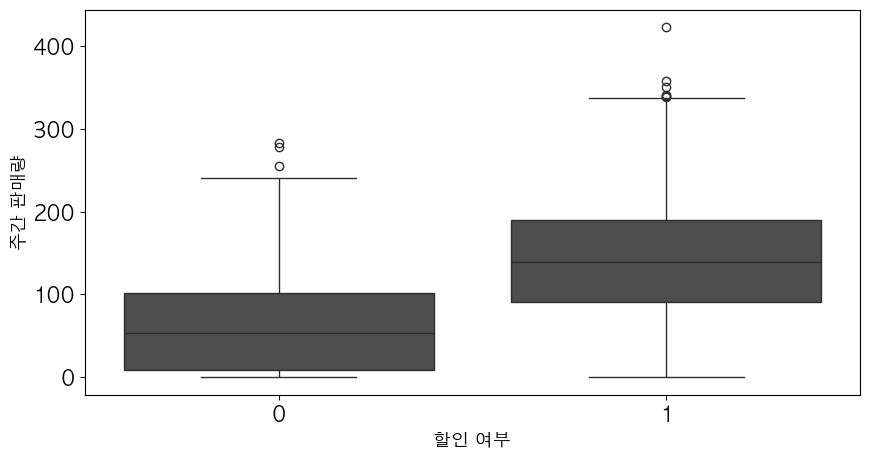

In [21]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
sns.boxplot(y="weekly_amount_sold", x="is_on_sale", data=xs, ax=ax)

ax.set_xlabel("할인 여부", fontsize = 13)
ax.set_ylabel("주간 판매량", fontsize = 13)
ax.tick_params(axis='both', which='major', labelsize=15)

할인 여부가 판매량 증가의 원인이라고 볼 수 있을까?  
- 그렇게 판단할 경우, 연관관계를 인과관계로 착각하는 것일 수 있음  
- 판매량이 많게 나타난 이유는 상품을 가장 많이 판매하는 대기업들이 더 공격적으로 가격을 낮출 여유가 있기 때문일 수 있음
- 또는 고객들이 가장 많이 구매하는 시기인 크리스마스 쯤 할인을 진행한 영향일 수 있음  

중요한 것은, 동일한 회사에서 할인이 진행되는 상황과 그렇지 않은 상황을 동시에 관측할 수 있어야만 가격할인이 판매량에 미치는 실제 효과를 확신할 수 있다는 점
- 이러한 두 가지 **반사실(CounterFactual)** 상황을 비교함으로써 가격할인 효과를 파악할 수 있음
    - 그러나, 인과추론의 근본적인 문제인 '동일 대상의 두 상황을 동시에 관측할 수 없으므로' 다른 방법을 찾아야 함

### 잠재적 결과(Potential Outcome)
잠재적 결과는 실제로 일어나지 않았으나 발생할 수 있는 결과.  
대신, 처치를 받은 경우에 무슨 일이 일어났을지를 나타냄

관측할 수 있는 한 가지 잠재적 결과를 **사실적 결과(factual outcome)**, 관측할 수 없는 다른 한 가지 결과를 **반사실적 결과(counterfactual outcome)** 이라고 함.
- 예를 들어, 실험 대상 $i$가 처치받은 후 어떤 일이 일어나는지 사실적 결과 $Y_{1i}$를 관측할 수 있음
- 반면, 실험 대상 $i$가 처치 받지 않으면 어떤 일이 일어날지 알 수 없음
    - 즉, $Y_{0i}$는 반사실적 결과이므로 관측할 수 없음


<**표현 방법**>
- 실험대상 i가 처치를 받지 않았을 때 얻을 수 있는 결과 : $Y_i(0)$
- 실험대상 i가 처치를 받았을 때 얻을 수 있는 결과 : $Y_i(1)$

또는 아래와 같이 표현하기도 함

- $Y_{0i}$ : 실험대상 i가 처치를 받지 않은 잠재적 결과 
- $Y_{1i}$ : **같은 실험대상 i**가 처치를 받은 잠재적 결과  


인과추론의 근본적인 문제로 인해 잠재적 결과 중 하나만 관측할 수 있으므로 **개별 처치 효과(ITE, Individual Treatment, Effect)**를 알 수 없음.
그러나, 비록 개별 효과는 알 수 없지만 다음 3가지 인과 추정량을 정의할 수 있음

- (1) 평균 처치효과(ATE, average treatment effect)
    - $ATE = E[Y_{1i} - Y_{0i}]$
        - $ATE = E[AmountSold_{1i} - AmountSold_{0i}]$

- (2) 실험군에 대한 평균 처치효과(ATT, averge treatment effect on the treated)
    - $ATT = E[Y_{1i} - Y_{0i} | T=1]$
        - $ATT = E[AmountSold_{1i} - AmountSold_{0i} | IsOnSales=1]$

- (3) 조건부 평균 처치효과(conditional average treatment effect)
(ex. 크리스마스 주간의 할인 여부가 미치는 영향)
    - $CATE = E[Y_{1i} - Y_{0i} | X=x]$
        - $CATE = E[AmountSold_{1i} - AmountSold_{0i} | weeksToXmas=0]$

현실에선 두 가지 잠재적 결과를 모두 볼 수 없지만, 반사실도 볼 수 있다고 가정하고 아래 가정을 통해 인과추론을 좀 더 이해해보자.  
- i = 실험 대상
- y0, y1 = 잠재적 결과
- t = 처치 여부 (할인)
- x = 크리스마스까지의 시간을 나타내는 covariance
- y = 결과 (판매량)
- te = y1 - y0

In [12]:
tt = pd.DataFrame(dict(
        i= [1,2,3,4,5,6],
        y0=[200,120,300,450,600,600],
        y1=[220,140,400,500,600,800],
        t= [0,0,0,1,1,1],
        x = [0,0,1,0,0,1],
        y= [200,120,300,500,600,800],
        te=[20,20,100,50,0,200]
))
tt

,i,y0,y1,t,x,y,te
0,1,200,220,0,0,200,20
1,2,120,140,0,0,120,20
2,3,300,400,0,1,300,100
3,4,450,500,1,0,500,50
4,5,600,600,1,0,600,0
5,6,600,800,1,1,800,200


현실에선 불가능하지만 위 데이터를 통해 $AmountSold_{0}$와 $AmountSold_{1}$을 알 수 있음  
여기서 $ATE$는 마지막 컬럼에 대한 평균 즉, 개별 처치 효과(ITE)에 대한 평균.

    - $ATE=(20 + 20 + 100 + 50 + 0 + 200)/6 = 65$

즉, 가격 할인을 통해 판매량이 평균 65개 증가했음을 의미.  

$ATT$는 $T=1$일 때 마지막 열의 평균.

    - $ATT=(50 + 0 + 200)/3 = 83.33$

가격을 할인한 회사는 가격 할인에 따른 판매량이 평균 83.33개 증가.  

추가로, 크리스마스 1주일 전이라는 조건부 평균 효과는 3번 회사와 6번 회사의 평균에 해당함.

    - $Cate(x = 1) = (100 + 200)/2 = 150$

그리고 $x = 0$일 때 크리스마스 주에 대한 평균 처치효과를 의미함.(회사 1, 2, 4, 5번)

    - $Cate(x = 10) = (20 + 20 + 50 + 0)/4 = 22.5$

즉, 회사가 크리스마스 주간에 가격을 할인했을 때(22.5개 증가)보다 크리스마스 1주일 전에 할인했을 때(150개 증가)가 훨씬 더 많은 효과를 보인다는 것을 의미함.  


그러나, 현실에선 아래와 같은 데이터를 마주하게 됨

In [14]:
tt2 = pd.DataFrame(dict(
        i= [1,2,3,4,5,6],
        y0=[200,120,300,np.nan,np.nan,np.nan],
        y1=[np.nan, np.nan, np.nan,500,600,800],
        t= [0,0,0,1,1,1],
        x = [0,0,1,0,0,1],
        y= [200,120,300,500,600,800],
        te=[np.nan, np.nan, np.nan, np.nan, np.nan, np.nan]
))
tt2

,i,y0,y1,t,x,y,te
0,1,200.0,NaN,0,0,200,NaN
1,2,120.0,NaN,0,0,120,NaN
2,3,300.0,NaN,0,1,300,NaN
3,4,NaN,500.0,1,0,500,NaN
4,5,NaN,600.0,1,0,600,NaN
5,6,NaN,800.0,1,1,800,NaN


위 표(tt2)는 이전의 표(tt)와 달리 인과효과를 계산하기 위해 확실히 이상적이지 않음. 그런데 여전히 처치된 그룹의 평균을 취하여 처치되지 그룹의 평균과 비교할 수 없을까?  
즉, $ATE=(500+600+800)/3 - (200+120+300)/3 = 426.67$ 하는 건? 절대 안됨!  
연관관계를 인과관계로 착각하는 중대한 오류를 저지르는 셈.  
인과추론의 골치 아픈 문제인 **편향(Bias)** 에 대해 살펴보자.


### 편향(Bias): 연관관계와 인과관계를 다르게 만드는 요소
가격할인이 기업의 판매량을 높인다는 주장에 부딪혔을 때, 할인한 기업은 가격할인 없이도 어차피 더 많이 팔았을 것이라고 의문을 제기할 수 있음. 해당 기업들은 규모가 더 크고 더 공격적으로 할인할 여유가 있었을 수 있기 때문.  
즉, 할인한 회사(실험군)와 할인하지 않은 회사(대조군)을 동등하게 비교할 수 없는 것.  

잠재적 결과 표기법에서 처치받은 $Y_0$가 처치받지 않은 $Y_0$는 다름. 처치받은 $Y_0$는 **반사실**.  
실제로 반사실을 관찰할 수 없으나 해당 부분에 대해 추론은 할 수 있음.  
반사실을 추론하기 위한 경우에서는 세상이 어떻게 돌아가는지에 대한 이해(도메인 지식 등)를 활용하여 더 합리적으로 추론할 수 있음. 
위 예시의 경우, 가격을 할인한 회사의 $Y_0$가 할인하지 않은 회사의 $Y_0$보다 더 크다고 말할 수 있음.  
다시 말해, 가격을 할인할 수 있는 회사들은 더 많은 판매량에 영향을 주는 다른 요인들도 이미 갖추고 있을 수 있음.  

연관관계가 인과관계가 아닌 경우인 이유에 대해 기본적인 수식으로 보여줄 수 있음  
연관관계는 $E[Y|T=1] - E[Y|T=0]$로 측정되는데, 이는 할인을 진행한 회사의 평균 판매량에서 할인하지 않은 회사의 평균 판매량을 뺀 값임.  
반면 인과관계는 $E[Y_1 - Y_0] (E[Y | do(t=1)] - E[Y | do(t=0)])$로 측정.

연관관계를 측정하고 관찰된 결과를 잠재적 결과로 바꾼다면?  
처치받은 경우 관찰된 결과는 $Y_1$이고 받지 않은 경우 관찰된 결과는 $Y_0$ .

$
E[Y|T=1] - E[Y|T=0] = E[Y_1|T=1] - E[Y_0|T=0]
$

이제, $E[Y_0|T=1]$를 더하고 뺀다. 이 부분은 반사실 결과에 대한 부분이며 처치받지 않았다면 처치의 결과가 어떠했을 것인지를 보여줌.

$
E[Y|T=1] - E[Y|T=0] = E[Y_1|T=1] - E[Y_0|T=0] + E[Y_0|T=1] - E[Y_0|T=1]
$

마지막으로 수식을 재정리하고, 기댓값을 합친 이후는 다음과 같음

$
E[Y|T=1] - E[Y|T=0] = \underbrace{E[Y_1 - Y_0|T=1]}_{ATT} + \underbrace{\{ E[Y_0|T=1] - E[Y_0|T=0] \}}_{BIAS}
$

- (1) 연관관계 = 처치에 대한 처치 효과에 bias를 더한 것. 
- (2) **편향** : 실험군과 대조군이 처치를 받지 않은 경우, 처치 전에 실험군과 대조군이 어떻게 다른지를 나타냄.
- (3) 교란변수(Confounding variable)
    - 통제할 수 없는 변수들
    - 원인 변수와 결과 변수에 동시에 영향을 주면서 두 변수 사이에 실제 인과관계가 없는 허위 상관관계를 만드는 제3의 변수. 독립변수와 결과 변수에 모두 관련되어 있어 연구 결과의 타당성을 왜곡시키므로, 연구 설계 단계에서 무작위화, 제한, 매칭(짝짓기) 등의 방법으로 통제 

<Figure size 640x480 with 0 Axes>

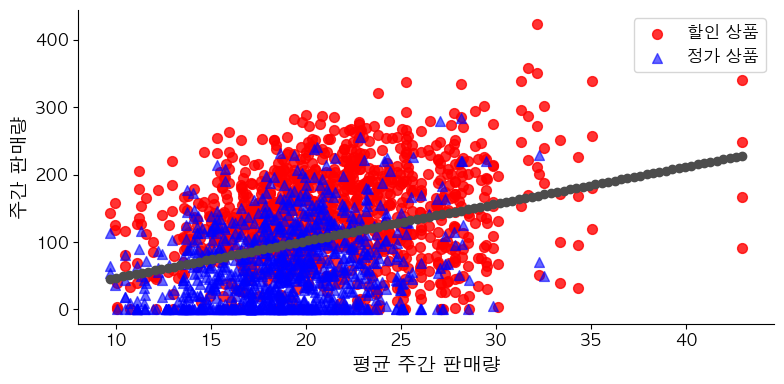

In [27]:
plt.rc('font', size=12)
fig = plt.figure()    

sns.lmplot(data=xs,
           ci=None,
           x="avg_week_sales",
           y="weekly_amount_sold",
           scatter=False,
           height=4, aspect=2)

# 색상을 더 구분하기 쉽게 변경
plt.scatter(x=xs.query("is_on_sale==1")["avg_week_sales"],
            y=xs.query("is_on_sale==1")["weekly_amount_sold"],
            label="할인 상품",
            color='red', alpha=.8, marker='o', s=50)

plt.scatter(x=xs.query("is_on_sale==0")["avg_week_sales"],
            y=xs.query("is_on_sale==0")["weekly_amount_sold"],
            label="정가 상품",
            color='blue', alpha=.6, marker='^', s=50)

plt.xlabel("평균 주간 판매량", fontsize=14)
plt.ylabel("주간 판매량", fontsize=14)
plt.legend(fontsize=12)
plt.tight_layout()

**$E[Y_0|T=0] = E[Y_0|T=1]$** 이라면 연관관계는 인과관계와 같다. 
$E[Y_0|T=0] = E[Y_0|T=1]$는 실험군과 대조군이 비교 가능하다는 것을 의미. 또는 실험군이 처치를 받지 않았을 때 $Y_0$를 관찰할 수 있다면, 그 결과는 처치를 받지 않은 것과 같을 것이므로 결과적으로 bias는 사라질 것.

$
E[Y|T=1] - E[Y|T=0] = E[Y_1 - Y_0|T=1] = ATT
$
또한 처치받은 그룹과 처치받지 않은 그룹이 처치 자체에서만 다른 경우, $E[Y_0|T=0] = E[Y_0|T=1]$이고 처치를 받은 그룹에 대한 인과효과는 처치를 받지 않은 그룹과 같습음(두 그룹이 매우 유사하기 때문이에요).

$
\begin{align}
E[Y_1 - Y_0|T=1] &= E[Y_1|T=1] - E[Y_0|T=1] \\
&= E[Y_1|T=1] - E[Y_0|T=0] \\
&= E[Y|T=1] - E[Y|T=0]
\end{align}
$

위와 같이 비교가능한 그룹일 경우 **두 집단의 평균차이가 인과효과** O.

$
E[Y|T=1] - E[Y|T=0] = ATT
$

처치 그룹과 처치되지 않은 그룹이 처치에서만 다른 경우 -> $E[Y_1|T=0] = E[Y_1|T=1]$  
처치 전 교환가능(exchangeable, 비교가능)하며 처치 후에도 실험군과 대조군이 교환 가능해요.
다음과 같이 표현.   
- $E[Y_1 - Y_0|T=1]=E[Y_1 - Y_0|T=0]$
- $E[Y|T=1] - E[Y|T=0] = ATT = ATE$  

편향을 제거하고 실험군과 대조군을 비교 가능하게 하는 방법이 결국 인과추론의 핵심  
이를 통해 모든 차이가 평균적인 처치 효과(ATE)만으로 추정할 수 있게끔 하는 것. 

### 독립성 가정과 랜덤화

결국, 실험군과 대조군이 서로 교환 가능한지가 인과추론의 핵심적인 가정.  
독립성 가정은 $E[Y_{0}|T] = E[Y_{0}]$, 즉 처치가 잠재적 결과에 관한 어떠한 정보도 제공하지 않음을 의미함.  
어떤 실험 대상이 처치를 받았다고 해서 처치 받지 않았을 경우($Y_{0}$)의 결과가 더 낮거나 더 높음을 의미하지 않음.  
가격할인 예시에서 단순히 모든 회사가 할인하지 않았다면 할인하기로 한 회사와 그렇지 않은 회사를 구분할 수 없다는 것과 같음.  

인과추론 문제는 다음과 같은 두 단계로 나뉨
- 1. 식별(identification) : 관측 가능한 데이터로 인과 추정량을 표현하는 방법을 알아내는 단계
- 2. 추정(estimation) : 실제로 데이터를 사용하여 앞서 식별한 인과 추정량을 추정하는 단계  

랜덤화
- 랜덤화를 통해 실험 대상에 처치가 무작위로 이루어지므로 잠재적 결과는 물론 어떤 변수와도 독립적이게 됨
- 독립성 가정을 강제적으로 만족  

**실제 사례 : 멤버십 프로그램**  
추가 요금을 지불해 멤버십 프로그램에 참여하면 더 높은 할인율, 빠른 배송, 반품 수수료 면제, 다양한 고객 서비스를 누릴 수 있는 멤버십 프로글팸을 진행했다. 해당 프로그램의 효과를 파악하기 위해 무작위로 표본을 추출한 뒤, 일부 고객에게만 프로그램을 공개했다. 해당 고객들은 프로그렘에 참여할지 말지 직접 선택할 수 있었다. 실험 종료 후 확인해보니 멤버십에 참여한 고객들이 대조군보다 훨씬 더 높은 수익성을 보였으며 고객 서비스 시간도 줄었다.  
그렇다면, 멤버십 프로그램이 매출 증가와 고객 서비스 시간 단축이라는 두 마리 토끼를 다 잡은 것일까?  
**그렇지 않다.*  
멤버십 프로그램의 참여 자격은 무작위로 선정했지만, 선정된 그룹의 고객 스스로 참여 여부를 선택할 수 있었다. 멤버십 자격을 무작위로 배정하면 프로그램에 참여할 수 있는 고객과 그렇지 않은 고객이 비슷해진다. 그러나, 대상자 중 프로그램 참여를 선택한 고객은 일부이며 이 '선택'은 자발적이었으므로 무작위로 이루어지지 않았다. 즉, 원래 구매율이 높은 고객들만 참여를 선택하고 그렇지 않은 고객들은 참여하지 않았을 수 잇다. 프로그램 참여 자격은 무작위로 선정했지만, '프로그램 참여'는 무작위로 선정되지 않은 것.  

따라서, 프로그램에 참여한 고객과 참여하지 않은 고객을 비교할 수 없다.  

- $E[Revenues_{0}|OptIn = 1] > E[Revenues_{0}|OptIn = 0]$

즉, 멤버십 프로그램에 참여한 고객에게서 멤버십 프로그램과 상관없이 더 많은 매출이 발생했음을 의미

## Week 03 - 2장 무작위 실험 및 기초 통계 리뷰

**연관관계는 ATT와 편향의 합으로 설명 가능**  
- $E[Y|T=1] - E[Y|T=0] = \underbrace{E[Y_1 - Y_0|T=1]}_{ATT} + \underbrace{\{ E[Y_0|T=1] - E[Y_0|T=0] \}}_{BIAS}$


연관관계는 편향이 존재하지 않을 때 인과관계가 될 수 있음
- $E[Y_0|T=0]=E[Y_0|T=1]$를 만족한다면 편향은 없을 것  
- 대조군과 실험군이 처치를 받은 것을 제외하고 타겟군과 대조군이 동등하거나 유사하다면 인과관계가 있다고 추정할 수 있음(대조군의 결과가 실험군의 반사실적 결과와 동등할때 연관성이 인과관계가 되는 것이 성립)


편향을 어떻게 없앨 수 있는가?
- **무작위 실험(Randomised Experiments)**
- 실험군과 대조군에 대해 대상을 랜덤하게 분배
- 잠재적 결과를 처치로부터 독립적으로 만들어 편향을 제거

- $(Y_0, Y_1) \perp\!\!\!\perp T$
    - 처치와 결과 사이의 독립 X
    - 잠재적 결과가 처치와 독립적이길 바람

### 사례

온라인 쇼핑 시장이 커지면서 이커머스 회사들은 전환율을 조금이라도 올리려고 많은 실험들을 진행. 
예를 들어, 어떤 회사가 결제 단계에서 **"구매하기" 버튼 색깔**을 바꿔보기로 했다고 해보자.  
원래는 파란색 버튼이었는데 더 눈에 잘 띄게 **주황색 버튼**으로 변경하는 UI 실험. 

그렇다면, 버튼 색깔을 바꿨을 때 실제로 구매 전환율에 영향을 줄까?  

#### 단순 비교의 함정
여전히 많은 회사들에서 AB 테스트 진행 시 범하는 실수 : 단순 비교
- 새 버튼을 본 사람들의 구매율 vs 기존 버튼을 본 사람들의 구매율  

But, 이 방식은 아래와 같은 문제점이 존재함.

- **긍정 편향 (Positive Bias):**  
  새 버튼이 주로 **모바일 사용자**한테만 노출됐다고 해보자.  
  원래 모바일 사용자가 충성도가 더 높을 수도 있으므로
  버튼 색상 변경 효과가 없더라도 새 버튼 그룹의 구매율이 더 높게 나온다.  
  $$E[Y_0|T=1] > E[Y_0|T=0]$$  

- **부정 편향 (Negative Bias):**  
  반대로 새 버튼이 **신규 방문자** 위주로 노출됐다고 해보자.  
  원래 신규 방문자는 구매율이 낮으니까, 실제 버튼 효과가 있더라도  
  오히려 새 버튼 그룹의 구매율이 낮게 나올 수 있다.
  $$E[Y_0|T=1] < E[Y_0|T=0]$$  

즉, 그냥 비교하면 효과가 있는지 없는지 제대로 알 수 없다. 
보이지 않는 교란(bias)이 끼어들 수 있기 때문.


#### 무작위 실험(Randomised Experiment)
그래서 진짜로 버튼 색깔 효과를 보려면 **무작위 배정(randomisation)** 이 필요함.

- 고객을 랜덤으로 A/B 그룹으로 나눔  
  - A 그룹: 기존 파란 버튼 (대조군)  
  - B 그룹: 새로운 주황 버튼 (실험군)  

이렇게 하면 두 그룹은 버튼 색깔만 다르고, 나머지 특성(나이, 성별, 기기, 충성도 등)은 평균적으로 같아질 수 있음 
그래서 두 그룹 전환율 차이는 곧 버튼 색깔의 효과라고 인과적으로 말할 수 있게 됨


#### 예시 사례
회사가 무작위로 고객을 나눠서 2주간 실험을 진행했다고 해보자.  
- A 그룹: 50,000명 중 4,500명이 구매 (구매율 9%)  
- B 그룹: 50,000명 중 5,250명이 구매 (구매율 10.5%)  

결과는 주황 버튼 그룹의 전환율이 **1.5%p 높음**.  
이 차이가 우연이 아닐까 싶으면 가설 검정을 통해 p-value 계산 → 유의수준 0.05 이하라면 “버튼 색깔이 전환율에 영향을 줬다”고 결론낼 수 있음.  
- 물론, 실제 실무에선 p-value 만으로 유의성을 검정하고 넘어가진 않음

---

#### 요약
- 단순 비교는 편향 때문에 인과효과를 보장하지 못함  
- 무작위 실험은 **$(Y_0, Y_1) \perp\!\!\!\perp T$** 조건을 만족시켜서 처치 효과를 깔끔하게 볼 수 있게 해줌  
- 결국, 버튼 색깔 같은 작은 UI 변경도 무작위 실험 없이는 정확히 판단하기 어려움

### 통계적 유의성 (Statistical Significance)


#### 1. 가설 설정
예: "신약에 효과가 있다"라는 가설을 검증  
- **귀무가설 $H_0$**: 신약에 효과가 없다. (모집단 A, B의 평균 동일)  
- **대립가설 $H_1$**: 신약에 효과가 있다. (모집단 A, B의 평균 다름, 양측가설)

$$
H_0: \mu_A = \mu_B \quad,\quad H_1: \mu_A \neq \mu_B
$$

가설 검정은 **귀류법**의 구조를 따른다.  
- 주장(귀무가설)이 참이라고 가정  
- 그 가정에서 모순 발견 시 귀무가설 기각  


#### 2. 가설 검정과 표본

- 가설 검정의 대상은 **모집단**  
- 하지만 실제로는 표본 데이터를 활용 → 표본평균과 모평균은 다를 수 있음  
- 따라서 표본 평균 차이가:
  - 단순한 분산 때문인지  
  - 실제 신약 효과 때문인지  
  확인하는 게 핵심이다.  


#### 3. p-value 이해하기

(1) 귀무가설이 옳은 세계 가정
- $\mu_A = \mu_B$ 라고 가정  
- 표본평균의 차이는 여러 번 추출 시 정규분포 형태  
- 평균 차이 분포는 $0$을 중심으로 대칭  

(2) 현실 데이터와 비교
- 실제 데이터에서 얻은 차이가 귀무가설 세계에서 **극히 드물게** 발생한다면?  
  → 귀무가설 기각  

**p-value 정의**  
$$
p\text{-value} = P(\text{관찰된 값 이상으로 극단적인 값} \mid H_0 \text{가 참})
$$


#### 4. 유의성 해석

- 유의수준 $\alpha = 0.05$  
- $p < \alpha$: 귀무가설 기각 → "통계적으로 유의미한 차이 발견"  
- $p \geq \alpha$: 귀무가설 기각 불가 → "통계적으로 유의미한 차이 발견하지 못함"  


**통계적 유의성을 무조건 신뢰해선 안 되는 이유**

- 1) $p$-value ≠ 대립가설이 참
  - p-value는 단지 "귀무가설을 지지할 근거 부족"을 의미  
  - 대립가설이 참이라는 증거 자체는 아님  

- 2) $p$-value ≠ 효과 크기
  - **효과 크기 (Effect Size)**: 차이의 **실질적 의미**를 나타냄  

  - (a) Cohen's d
    $$
    d = \frac{\bar{X}_1 - \bar{X}_2}{s_p}
    $$
    - $s_p$: 풀링 표준편차  
    - $d = 0.2$ (작음), $0.5$ (중간), $0.8$ 이상 (큼)

  - (b) 상대적 위험도 (Relative Risk, RR)
    $$
    RR = \frac{p_{\text{treatment}}}{p_{\text{control}}}
    $$
    - $RR = 1$ → 차이 없음  
    - $RR > 1$ → 실험군 효과 ↑  
    - $RR < 1$ → 실험군 효과 ↓  

  - (c) 신뢰구간 (Confidence Interval)
    - 예시: 두 전환율 차이 = 0.01167, 표준오차 = 0.01196  
    - 95% CI = $[-0.0117, 0.0351]$  
    - CI가 0을 포함 → 유의미하지 않음  


- 3) $p$-value가 작아지는 경우
  - 표본 크기가 너무 클 때 → 작은 차이도 유의하게 나옴  
  - 표본 크기가 너무 작을 때 → 차이를 못 잡음  
  - 다중 검정 시 → p-value 작은 값이 우연히 자주 발생  
    - → 보정 필요 (예: Bonferroni 교정)  


### A/B 테스트 설계 시 고려 요소

A/B 테스트를 설계할 때 반드시 고려해야 하는 주요 항목
- **MDE (Minimum Detectable Effect)**: 비즈니스적으로 유의미한 최소 차이  
- **검정력 (Power)**: 실제로 차이가 있을 때 그 차이를 발견할 확률 (보통 80%)  
- **표본 크기 (Sample Size)**: 실험에 필요한 사용자 수  
- **실험 기간 (Test Duration)**: 표본을 수집하는 데 필요한 기간  
- **유의수준 (Alpha)**: 보통 0.05, 1종 오류(귀무가설이 참인데 기각)의 허용 한계  


#### 1. MDE (Minimum Detectable Effect)

- A/B 테스트에서 **탐지하고자 하는 최소 효과 크기**  
- 실험 설계 단계에서 미리 정의해야 함  
- 예: 기존 전환율 10%, 탐지하고 싶은 차이 2%p → MDE = 0.02  

**효과 크기(Effect Size) 계산식**  
$$
\text{effect\_size} = \frac{\text{MDE}}{\sqrt{p \cdot (1-p)}}
$$

- $p$: 기존 전환율  
- MDE가 작을수록 → 작은 변화를 탐지하려면 **더 많은 표본** 필요  
- MDE가 클수록 → 적은 표본으로 충분하지만 작은 효과는 놓칠 수 있음  

> **주의**: 실험 결과가 MDE보다 작은 차이를 보여도, p-value가 유의하다면 통계적으로 의미는 있음. 다만, **비즈니스적으로 의미 있는 차이인지** 별도 검토 필요.



#### 2. 검정력 (Power)

- 정의: **귀무가설이 거짓일 때, 귀무가설을 기각할 확률**  
- 수식:  
  $$
  \text{Power} = 1 - \beta
  $$

  - $\beta$: 2종 오류 (대립가설이 참인데 귀무가설을 기각하지 않는 오류)  
- 실무에서는 보통 0.8 (80%) 사용  
- 의미: 실제로 효과가 있을 때 그 효과를 감지할 확률이 80%  

**검정력에 영향을 주는 요인**  
1. **표본 크기 ↑** → 검정력 ↑  
2. **효과 크기 ↑** → 검정력 ↑  
3. **유의수준 α ↑** → 검정력 ↑ (하지만 1종 오류 위험 커짐)  
4. **분산 ↓** → 검정력 ↑  



#### 3. 표본 크기 계산

- 표본 크기를 계산하기 위해 필요한 값:  
  - 기존 전환율 (baseline conversion rate)  
  - MDE  
  - 유의수준 α  
  - 검정력 (보통 0.8)  



In [29]:
#### ✔️ 파이썬 코드 예시


from statsmodels.stats.power import TTestIndPower, NormalIndPower
import math

baseline_cvr = 0.02  # 기존 전환율 2%
mde = 0.03           # 최소 탐지 효과 3%p
alpha = 0.05         # 유의수준
power = 0.8          # 검정력 80%

# 효과 크기 계산 (표준화된 효과 크기)
effect_size = mde / math.sqrt(baseline_cvr * (1 - baseline_cvr))
print(f"Effect Size: {effect_size:.4f}")

# (1) Z-test (표본 크기 충분할 때)
normal_power_analysis = NormalIndPower()
sample_size_z = normal_power_analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power)
print(f"Z-test 표본 크기: {sample_size_z:.0f}")

# (2) T-test (표본 크기 작거나 분산 모를 때)
t_test_power_analysis = TTestIndPower()
sample_size_t = t_test_power_analysis.solve_power(effect_size=effect_size, alpha=alpha, power=power)
print(f"T-test 표본 크기: {sample_size_t:.0f}")

Effect Size: 0.2143
Z-test 표본 크기: 342
T-test 표본 크기: 343
